<a href="https://colab.research.google.com/github/sofialuiza15/projetos-ml/blob/main/Convers%C3%A3o_de_cores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recuperação de cor em imagem em preto e branco


Importando o pytorch e as bibliotecas necessárias para o sucesso da implementação.

In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split
import numpy as np
import matplotlib.pyplot as plt
from skimage import color

Verificação e configuração do ambiente de execução para as etapas de treino serem mais rápidas.

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

Device: cuda


Nesse bloco de código é onde baixamos e normalizamos o dataset que será utilizado para o treinamento da rede neural. Normalizamos os valores e organizamos os dados para serem convertidos para Lab (necessária para uma melhor análise de contraste, luminosidade e cor).

In [ ]:
class STLColorizationDataset(torch.utils.data.Dataset):
    def __init__(self):
        self.dataset = torchvision.datasets.STL10(
            root='./data',
            split='train',
            download=True
        )

        self.dataset_extra = torchvision.datasets.STL10(
            root='./data',
            split='test',
            download=True
        )

        self.data = self.dataset.data
        self.data_extra = self.dataset_extra.data

        self.images = np.concatenate([self.data, self.data_extra], axis=0)

        self.transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        img = torch.tensor(img).permute(1, 2, 0).numpy() / 255.0

        lab = color.rgb2lab(img)
        lab = torch.tensor(lab).permute(2, 0, 1)

        L  = lab[0:1] / 50.0 - 1.0
        ab = lab[1:3] / 110.0

        return L.float(), ab.float()

Nesse bloco de código definimos quais dados serão para teste e quais serão para treino, os valores são, respectivamente, 1300 e 11700.

In [ ]:
full_dataset = STLColorizationDataset()

train_size = int(0.9 * len(full_dataset))
test_size  = len(full_dataset) - train_size

train_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, test_size]
)

print("Treino:", len(train_dataset))
print("Teste:", len(test_dataset))

Treino: 11700
Teste: 1300


Aqui é onde os dados são preparados e as características dos blocos de dados são definidas, como quantas imagens serão processadas por vez e a questão do embaralhamento de dados.

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

Aqui existe a definição de uma função que usaremos depois, contendo a convolução propriamente dita, a normalização dos valores de saída da convolução e a função de ativação (decide quais valores são relevantes e quais não são).

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

Nesse bloco de código logo abaixo, é onde temos a parte principal da U-net. Primeiro temos o ```Encoder```, a redução da imagem a um tamanho menor para a extração das características complexas da imagem, logo após temos o ```Bottleneck``` que é o ponto mais profundo da rede, onde temos a parte mais abstrata da imagem, onde ela fica muito pequena mas com muita informação. Por último fica o ```Decoder``` que pega o bottleneck e reconstrói a imagem em seu tamanho original, só que dessa vez, pintando a imagem com as cores que foram identificadas.

In [ ]:
class UNetColorization(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(1, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)

        self.pool = nn.MaxPool2d(2)

        self.middle = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 2, 1)

    def forward(self, x):

        # encoder
        d1 = self.down1(x)
        d2 = self.down2(self.pool(d1))
        d3 = self.down3(self.pool(d2))

        # bottleneck
        m = self.middle(self.pool(d3))

        # decoder
        u3 = self.up3(m)
        u3 = self.conv3(torch.cat([u3, d3], dim=1))

        u2 = self.up2(u3)
        u2 = self.conv2(torch.cat([u2, d2], dim=1))

        u1 = self.up1(u2)
        u1 = self.conv1(torch.cat([u1, d1], dim=1))

        return self.out(u1)

In [ ]:
model = UNetColorization().to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
for epoch in range(30):
    model.train()
    total_loss = 0

    for L, ab in train_loader:
        L = L.to(device)
        ab = ab.to(device)

        pred_ab = model(L)
        loss = criterion(pred_ab, ab)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f}")


Epoch 1 | Loss: 0.0799
Epoch 2 | Loss: 0.0739
Epoch 3 | Loss: 0.0726
Epoch 4 | Loss: 0.0723
Epoch 5 | Loss: 0.0719
Epoch 6 | Loss: 0.0716
Epoch 7 | Loss: 0.0715
Epoch 8 | Loss: 0.0713
Epoch 9 | Loss: 0.0709
Epoch 10 | Loss: 0.0707
Epoch 11 | Loss: 0.0704
Epoch 12 | Loss: 0.0702
Epoch 13 | Loss: 0.0702
Epoch 14 | Loss: 0.0700
Epoch 15 | Loss: 0.0699
Epoch 16 | Loss: 0.0696
Epoch 17 | Loss: 0.0695
Epoch 18 | Loss: 0.0692
Epoch 19 | Loss: 0.0688
Epoch 20 | Loss: 0.0688
Epoch 21 | Loss: 0.0685
Epoch 22 | Loss: 0.0683
Epoch 23 | Loss: 0.0682
Epoch 24 | Loss: 0.0684
Epoch 25 | Loss: 0.0679
Epoch 26 | Loss: 0.0675
Epoch 27 | Loss: 0.0674
Epoch 28 | Loss: 0.0671
Epoch 29 | Loss: 0.0669
Epoch 30 | Loss: 0.0667


Nesse bloco de código convertemos Lab para RGB, pois para visualização de imagens o RGB é utilizado, uma vez que o Lab é usado para análise das cores e caracteristicas da imagem. E comparamos as imagens, a passada como parametro, as cores que deveriam ser, e a imagem colorida com as cores que a rede neural identificou.

In [ ]:
def visualize_result(L, ab, pred_ab, n=3):
    for i in range(n):
        L_img = (L[i][0].numpy() + 1) * 50
        ab_gt = ab[i].permute(1, 2, 0).numpy() * 110
        ab_pr = pred_ab[i].permute(1, 2, 0).numpy() * 110

        lab_gt = np.concatenate([L_img[..., None], ab_gt], axis=2)
        lab_pr = np.concatenate([L_img[..., None], ab_pr], axis=2)

        rgb_gt = color.lab2rgb(lab_gt)
        rgb_pr = color.lab2rgb(lab_pr)

        plt.figure(figsize=(9, 3))
        plt.subplot(1, 3, 1)
        plt.imshow(L_img, cmap='gray')
        plt.title("Input")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(rgb_gt)
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(rgb_pr)
        plt.title("Predição")
        plt.axis("off")

        plt.show()


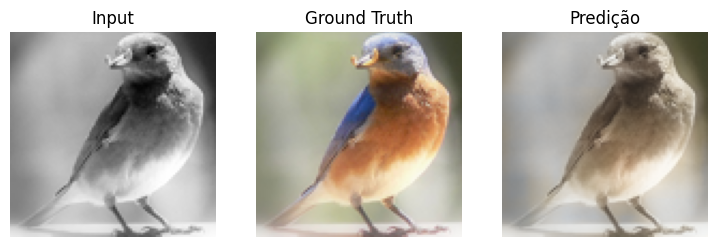

/tmp/ipython-input-2245717726.py:11: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 19 negative Z values that have been clipped to zero
  rgb_pr = color.lab2rgb(lab_pr)


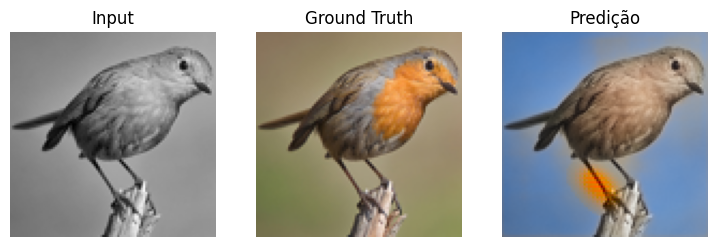

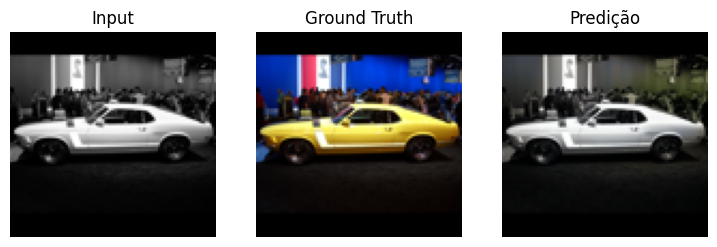

In [ ]:
model.eval()
with torch.no_grad():
    L, ab = next(iter(test_loader))
    pred_ab = model(L.to(device)).cpu()
    visualize_result(L, ab, pred_ab)